# ⏱️ Pipeline SLA Monitor

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-engineering-pro/pipeline-sla-monitor/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-engineering-pro/pipeline-sla-monitor/demo.ipynb)

> A data pipeline that lands *late*, runs *slow*, goes *stale*, or arrives *thin* usually breaks a consumer before anyone on the data team notices. This turns four plain-English promises per pipeline into a **compliance scorecard** you can page on.

**What this notebook covers**
1. Declare an **SLA** per pipeline: land-by time, max duration, freshness window, min rows.
2. Grade ~2 weeks of nightly runs against those promises.
3. Read the **fleet scorecard** and the **breach log**.
4. Chart compliance and the incidents behind it.
5. Plug in your own run history.

No warehouse, no API keys - pure standard library core.

## 1. The core idea

An SLA is a promise with four dimensions. A run **breaches** if it misses any of them:

| Dimension | Breach type | Promise |
|-----------|-------------|---------|
| Landing time | `LATE` | run finishes by a wall-clock deadline |
| Duration | `SLOW` | run completes within a time budget |
| Freshness | `STALE` | a *successful* run exists within N hours of now |
| Volume | `LOW_VOLUME` | run lands at least a floor number of rows |
| (any error) | `FAILED` | the run itself errored |

We grade every run, then roll it up to a per-pipeline **compliance %** and a fleet status.

In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from datetime import date, datetime, time, timedelta
from typing import Dict, List, Optional
import random


@dataclass
class SLA:
    landing_by: time          # run must FINISH by this time of day
    max_duration_min: int     # run must complete within this many minutes
    freshness_hours: int      # a good run must exist within this window of `now`
    min_rows: int             # a healthy run lands >= this many rows


@dataclass
class Run:
    pipeline: str
    start: datetime
    end: datetime
    rows: int
    failed: bool = False

    @property
    def duration_min(self) -> float:
        return (self.end - self.start).total_seconds() / 60.0


@dataclass
class Breach:
    pipeline: str
    run_date: date
    kind: str
    detail: str


@dataclass
class PipelineReport:
    pipeline: str
    total_runs: int
    breaches: List[Breach] = field(default_factory=list)
    is_stale: bool = False

    @property
    def breach_count(self) -> int:
        return len(self.breaches)

    @property
    def compliance_pct(self) -> float:
        if self.total_runs == 0:
            return 0.0
        bad_dates = {b.run_date for b in self.breaches}
        clean = self.total_runs - len(bad_dates)
        return round(100.0 * clean / self.total_runs, 1)

    @property
    def status(self) -> str:
        if self.is_stale or self.compliance_pct < 90:
            return "BREACH"
        if self.compliance_pct < 100:
            return "AT_RISK"
        return "HEALTHY"

print("Data model ready.")

Data model ready.


## 2. The evaluator

`evaluate()` walks each pipeline's run history and records a `Breach` for every missed
promise. `now` defaults to the latest run end time in the data, so the freshness check
is reproducible.

In [2]:
def evaluate(runs: List[Run], slas: Dict[str, SLA],
             now: Optional[datetime] = None) -> List[PipelineReport]:
    if now is None:
        now = max((r.end for r in runs), default=datetime(2026, 1, 1))

    by_pipeline: Dict[str, List[Run]] = {}
    for r in runs:
        by_pipeline.setdefault(r.pipeline, []).append(r)

    reports = []
    for name, sla in slas.items():
        prs = sorted(by_pipeline.get(name, []), key=lambda r: r.end)
        report = PipelineReport(pipeline=name, total_runs=len(prs))

        for run in prs:
            rd = run.end.date()
            if run.failed:
                report.breaches.append(Breach(name, rd, "FAILED", "run reported failure"))
                continue
            deadline = datetime.combine(run.end.date(), sla.landing_by)
            if run.end > deadline:
                late = (run.end - deadline).total_seconds() / 60.0
                report.breaches.append(Breach(name, rd, "LATE",
                    f"landed {late:.0f} min past {sla.landing_by:%H:%M}"))
            if run.duration_min > sla.max_duration_min:
                report.breaches.append(Breach(name, rd, "SLOW",
                    f"ran {run.duration_min:.0f} min (limit {sla.max_duration_min})"))
            if run.rows < sla.min_rows:
                report.breaches.append(Breach(name, rd, "LOW_VOLUME",
                    f"{run.rows:,} rows (floor {sla.min_rows:,})"))

        good = [r for r in prs if not r.failed]
        last_good = good[-1].end if good else None
        if last_good is None or (now - last_good) > timedelta(hours=sla.freshness_hours):
            report.is_stale = True
            age = "never" if last_good is None else f"{(now - last_good).total_seconds()/3600:.1f}h old"
            report.breaches.append(Breach(name, now.date(), "STALE",
                f"no good run within {sla.freshness_hours}h (last: {age})"))

        reports.append(report)
    return reports


def scorecard(reports: List[PipelineReport]) -> Dict[str, float]:
    n = len(reports)
    if n == 0:
        return {"pipelines": 0, "healthy": 0, "at_risk": 0, "breach": 0, "fleet_compliance": 0.0}
    return {
        "pipelines": n,
        "healthy": sum(1 for r in reports if r.status == "HEALTHY"),
        "at_risk": sum(1 for r in reports if r.status == "AT_RISK"),
        "breach": sum(1 for r in reports if r.status == "BREACH"),
        "fleet_compliance": round(sum(r.compliance_pct for r in reports) / n, 1),
    }

print("Evaluator ready.")

Evaluator ready.


## 3. Sample data - a small warehouse's nightly pipelines

Four pipelines over two weeks, seeded so the story is stable:

- **clickstream_daily** - always on time, fast, full → should be **HEALTHY**
- **orders_daily** - one upstream-delay night → **AT_RISK**
- **finance_close** - blows the duration budget three nights → **BREACH**
- **ml_features** - stops running after day 10 → **BREACH (stale)**

In [3]:
SAMPLE_SLAS = {
    "orders_daily":      SLA(time(6, 0),  45, 26,  8_000),
    "clickstream_daily": SLA(time(2, 0),  25, 26, 50_000),
    "finance_close":     SLA(time(7, 0),  90, 26,    500),
    "ml_features":       SLA(time(5, 30), 60, 26,  8_000),
}


def make_sample_runs(seed: int = 42) -> List[Run]:
    rng = random.Random(seed)
    runs, start_day = [], date(2026, 6, 29)
    for d in range(14):
        day = start_day + timedelta(days=d)

        start = datetime.combine(day, time(5, 0)) + timedelta(minutes=rng.randint(-5, 8))
        dur, rows = 30 + rng.randint(-4, 6), 10_000 + rng.randint(-800, 1500)
        if d == 5:
            start += timedelta(minutes=80)
        runs.append(Run("orders_daily", start, start + timedelta(minutes=dur), rows))

        start = datetime.combine(day, time(0, 40)) + timedelta(minutes=rng.randint(-5, 8))
        dur, rows = 12 + rng.randint(-2, 4), 62_000 + rng.randint(-4_000, 8_000)
        runs.append(Run("clickstream_daily", start, start + timedelta(minutes=dur), rows))

        start = datetime.combine(day, time(5, 30)) + timedelta(minutes=rng.randint(-5, 15))
        dur = 105 if d in (3, 8, 12) else 70 + rng.randint(-8, 12)
        runs.append(Run("finance_close", start, start + timedelta(minutes=dur), 900 + rng.randint(-100, 200)))

        if d <= 10:
            start = datetime.combine(day, time(4, 30)) + timedelta(minutes=rng.randint(-5, 10))
            dur = 40 + rng.randint(-5, 10)
            runs.append(Run("ml_features", start, start + timedelta(minutes=dur), 9_500 + rng.randint(-500, 800)))
    return runs


runs = make_sample_runs()
print(f"{len(runs)} runs across {len(SAMPLE_SLAS)} pipelines")

53 runs across 4 pipelines


## 4. Grade the fleet

In [4]:
reports = evaluate(runs, SAMPLE_SLAS)
card = scorecard(reports)
print("FLEET SCORECARD")
print("-" * 40)
for k, v in card.items():
    print(f"  {k:18}: {v}")
print()
for r in sorted(reports, key=lambda x: x.compliance_pct):
    flag = {"HEALTHY": "OK  ", "AT_RISK": "WARN", "BREACH": "FAIL"}[r.status]
    print(f"[{flag}] {r.pipeline:18} {r.compliance_pct:5}%  "
          f"{r.breach_count} breach(es){'  STALE' if r.is_stale else ''}")

FLEET SCORECARD
----------------------------------------
  pipelines         : 4
  healthy           : 1
  at_risk           : 1
  breach            : 2
  fleet_compliance  : 90.6

[FAIL] finance_close       78.6%  6 breach(es)
[FAIL] ml_features         90.9%  1 breach(es)  STALE
[WARN] orders_daily        92.9%  1 breach(es)
[OK  ] clickstream_daily  100.0%  0 breach(es)


## 5. The breach log

The scorecard tells you *who*; the breach log tells you *why* - the exact night and
reason. This is what you'd attach to a page or a Slack alert.

In [5]:
import pandas as pd

breaches = [{"pipeline": b.pipeline, "date": b.run_date.isoformat(),
             "type": b.kind, "detail": b.detail}
            for r in reports for b in r.breaches]
bdf = pd.DataFrame(breaches).sort_values(["date", "pipeline"]).reset_index(drop=True)
bdf

,pipeline,date,type,detail
0,finance_close,2026-07-02,LATE,landed 29 min past 07:00
1,finance_close,2026-07-02,SLOW,ran 105 min (limit 90)
2,orders_daily,2026-07-04,LATE,landed 54 min past 06:00
3,finance_close,2026-07-07,LATE,landed 22 min past 07:00
4,finance_close,2026-07-07,SLOW,ran 105 min (limit 90)
5,finance_close,2026-07-11,LATE,landed 15 min past 07:00
6,finance_close,2026-07-11,SLOW,ran 105 min (limit 90)
7,ml_features,2026-07-12,STALE,no good run within 26h (last: 73.6h old)


## 6. Visualize it

Two views: compliance % per pipeline (are we keeping the promise?) and a breach
breakdown by type (what kind of failure dominates?).

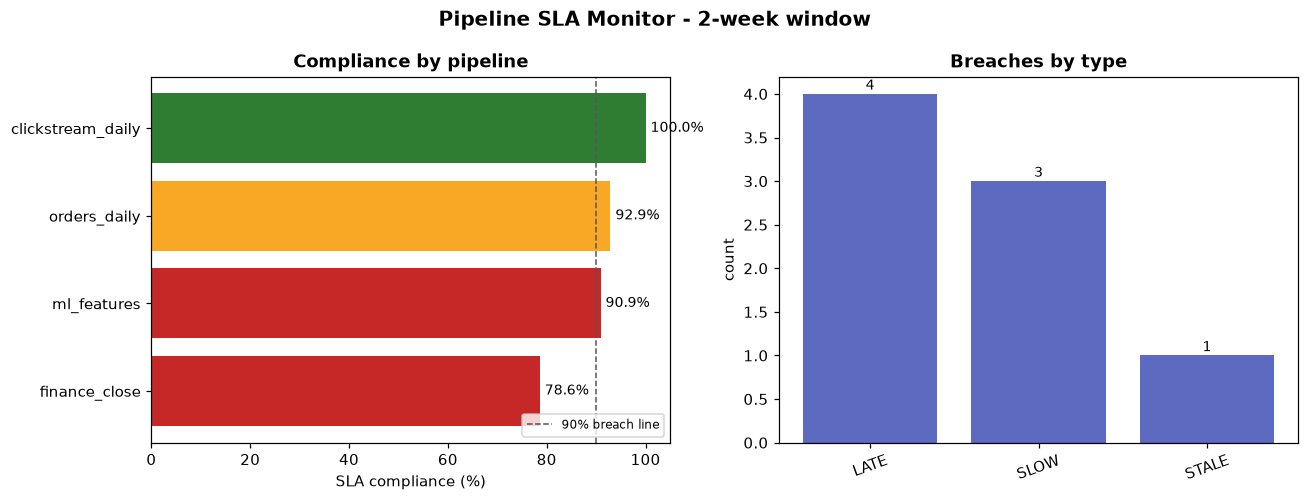

In [6]:
import matplotlib.pyplot as plt
from collections import Counter

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))

STATUS_COLOR = {"HEALTHY": "#2E7D32", "AT_RISK": "#F9A825", "BREACH": "#C62828"}
srt = sorted(reports, key=lambda r: r.compliance_pct)
names = [r.pipeline for r in srt]
vals = [r.compliance_pct for r in srt]
colors = [STATUS_COLOR[r.status] for r in srt]

bars = ax1.barh(names, vals, color=colors)
ax1.axvline(90, ls="--", lw=1, color="#555", label="90% breach line")
ax1.set_xlim(0, 105)
ax1.set_xlabel("SLA compliance (%)")
ax1.set_title("Compliance by pipeline", fontweight="bold")
for b, v in zip(bars, vals):
    ax1.text(v + 1, b.get_y() + b.get_height() / 2, f"{v}%", va="center", fontsize=9)
ax1.legend(loc="lower right", fontsize=8)

kinds = Counter(b.kind for r in reports for b in r.breaches)
order = ["LATE", "SLOW", "STALE", "LOW_VOLUME", "FAILED"]
kk = [k for k in order if k in kinds]
kv = [kinds[k] for k in kk]
ax2.bar(kk, kv, color="#5C6BC0")
ax2.set_ylabel("count")
ax2.set_title("Breaches by type", fontweight="bold")
for i, v in enumerate(kv):
    ax2.text(i, v + 0.05, str(v), ha="center", fontsize=9)
ax2.tick_params(axis="x", rotation=20)

fig.suptitle("Pipeline SLA Monitor - 2-week window", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("sla_dashboard.png", bbox_inches="tight", dpi=150)
plt.show()

## 7. Summary

| Pipeline | Status | Compliance | Headline issue |
|----------|--------|-----------|----------------|
| clickstream_daily | 🟢 HEALTHY | 100% | none |
| ml_features | 🔴 BREACH | 90.9% | stopped running - **stale** |
| orders_daily | 🟡 AT_RISK | 92.9% | one late landing |
| finance_close | 🔴 BREACH | 78.6% | repeatedly over duration budget |

The point: **compliance % alone hides the worst failure.** `ml_features` scores 90.9%
on its runs but is the scariest pipeline on the board - it silently stopped. Freshness
is the check that catches "the job that isn't running at all."


## 8. Try your own run history

Swap in your own SLAs and runs - the grader is the same.

In [7]:
# from datetime import datetime, time
#
# MY_SLAS = {
#     "my_pipeline": SLA(landing_by=time(6, 0), max_duration_min=30,
#                        freshness_hours=26, min_rows=1_000),
# }
# MY_RUNS = [
#     Run("my_pipeline",
#         start=datetime(2026, 7, 12, 5, 0),
#         end=datetime(2026, 7, 12, 5, 22),
#         rows=1_250),
#     # ... pull these from your orchestrator's run table (Airflow, dbt, etc.)
# ]
# for r in evaluate(MY_RUNS, MY_SLAS):
#     print(r.pipeline, r.status, r.compliance_pct, "%")

---
**Part of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** - a daily FDE portfolio.

For the interactive Streamlit version (fleet scorecard + filterable breach log):
```bash
pip install -r requirements.txt
streamlit run app.py
```